# Stage-1 as an MLP, trained sequentially or jointly

Koh et al. train a concept bottleneck three ways: independent, sequential
and joint. Ours has been sequential -- fit Stage-1, freeze it, then fit the
personal head. This notebook adds the two missing pieces and asks whether
either is better.

| mediator | Stage-1 | trained on |
|---|---|---|
| `emotion` | ridge, 512 -> 7 | emotion loss only |
| `emotion_mlp` | MLP, 512 -> 128 -> 7 | emotion loss only |
| `emotion_joint` | MLP, 512 -> 128 -> 7 -> 1 | emotion loss + score loss |

All three are then frozen, and the same ridge personal head is fitted on top
under anchor C. So the comparison is about Stage-1 alone.


## How the joint model is defined, and why

A literal joint fit would backpropagate one loss through Stage-1 and the
personal head together. The personal head here is per-user and sees about
100 ratings. Training Stage-1 through it would mean either

- making Stage-1 personal too: 512x7 weights fitted per user from 100
  samples, and the seven-parameters-per-user claim is gone; or
- training Stage-1 on the test users' own scores, which is the leak the v4
  split exists to prevent.

We tried the first once before: personalizing Stage-1 on 100 images
overfitted and CCC dropped.

So joint training here happens at the **population** level, on the training
group only:

```
loss = MSE(g(x), c_pop) + w * MSE(v . g(x) + b, y_pop)
```

`g` is the 512 -> 128 -> 7 trunk. The score head `v` reads the **seven
concepts**, not the hidden layer, so the score gradient is forced through
the bottleneck -- that is what makes it joint in Koh's sense. Routing the
score head off the hidden layer instead would shape the trunk while leaving
the seven concepts under emotion supervision only, which is sequential
training wearing a joint label. Stage-1 is then frozen, exactly like the
other two rows, so the parameter count and the protocol are unchanged.

Implementation: `_JointBottleneckNet` in `src/modeling/mediators.py`, plain
numpy with Adam (torch is not a dependency of the analysis environment).
The learning rate is chosen on the validation user group, on the combined
objective, by the same rule every other shared component follows.

**Budget caveat.** Both MLP rows use `stage1_mlp_max_iter = 300` and a
3-point learning-rate grid, set because a 2000-epoch, 5-point search on
4096-dimensional features costs hours per fold. This is a stated budget, not
a tuned optimum. A worse MLP result is therefore partly a statement about
the budget.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

UNIT = ['fold', 'domain', 'user_id']
COLS = {'population': 'pop', 'identity': 'Direct',
        'emotion': 'ridge Stage-1', 'emotion_mlp': 'MLP sequential',
        'emotion_joint': 'MLP joint'}
DESIGNS = ['ridge Stage-1', 'MLP sequential', 'MLP joint']

raw = pd.read_csv('../output/raw_all_final.csv', low_memory=False)
raw = raw[(raw.variant == 'C') & (raw['head'] == 'ridge')
          & raw.mediator.isin(COLS)]
print('backbones with joint results:',
      sorted(raw[raw.mediator == 'emotion_joint'].backbone.unique()))


backbones with joint results: ['clip']


## Table


In [2]:
def build(backbone):
    d = raw[raw.backbone == backbone]
    rows = []
    for n in (10, 25, 50, 100):
        g = d[d.n_train == n]
        if g.empty:
            continue
        g = g.groupby(UNIT + ['mediator'], as_index=False)['srocc'].mean()
        p = g.pivot_table(index=UNIT, columns='mediator', values='srocc')
        if not set(COLS) <= set(p.columns):
            continue
        p = p.dropna(subset=list(COLS))
        row = {'n_train': n}
        for m, label in COLS.items():
            row[label] = p[m].mean()
        for m, tag in (('emotion_mlp', 'MLP seq'), ('emotion_joint', 'MLP joint')):
            row[f'{tag} vs ridge p'] = wilcoxon(p[m], p['emotion'])[1]
        rows.append(row)
    return pd.DataFrame(rows).set_index('n_train') if rows else None


GREY_HEADERS = ['pop', 'Direct']
BLUE_HEADERS = DESIGNS


def show(df, caption):
    from IPython.display import display
    order = ([c for c in GREY_HEADERS + BLUE_HEADERS if c in df.columns]
             + [c for c in df.columns if c not in GREY_HEADERS + BLUE_HEADERS])
    df = df[order]
    styles = [
        {'selector': 'caption',
         'props': [('caption-side', 'top'), ('font-size', '106%'),
                   ('font-weight', '700'), ('padding-bottom', '8px'),
                   ('text-align', 'left')]},
        {'selector': 'th.col_heading', 'props': [('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('text-align', 'right'),
                                     ('padding', '4px 10px')]},
    ]
    for i, c in enumerate(df.columns):
        if c in GREY_HEADERS:
            bg, fg = '#37474f', 'white'
        elif c in BLUE_HEADERS:
            bg, fg = '#1565c0', 'white'
        else:
            bg, fg = '#eceff1', '#546e7a'
        styles.append({'selector': f'th.col_heading.col{i}',
                       'props': [('background-color', bg), ('color', fg),
                                 ('font-weight', '600')]})
    display(df.style.format({c: '{:.4f}' for c in df.columns})
            .set_caption(caption).set_table_styles(styles))


t = build('clip')
show(t, 'CLIP frozen | anchor C | ridge head | 3 seeds | 387 user-domain units')


,pop,Direct,ridge Stage-1,MLP sequential,MLP joint,MLP seq vs ridge p,MLP joint vs ridge p
n_train,,,,,,,
10,0.4159,0.4196,0.4138,0.4136,0.4132,0.1070,0.0095
25,0.4159,0.4312,0.4152,0.4137,0.4156,0.1271,0.3232
50,0.4159,0.4404,0.4232,0.4153,0.4147,0.0234,0.0227
100,0.4159,0.4559,0.4352,0.4138,0.4134,0.0000,0.0000


## Plot


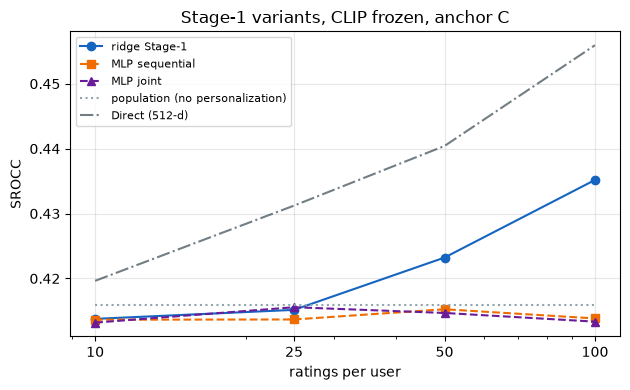

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
STYLE = {'ridge Stage-1': ('#1565c0', 'o', '-'),
         'MLP sequential': ('#ef6c00', 's', '--'),
         'MLP joint': ('#6a1b9a', '^', '--')}
for c in DESIGNS:
    col, mk, ls = STYLE[c]
    ax.plot(t.index, t[c], marker=mk, ls=ls, color=col, label=c)
ax.plot(t.index, t['pop'], color='#90a4ae', ls=':',
        label='population (no personalization)')
ax.plot(t.index, t['Direct'], color='#37474f', ls='-.', alpha=.7,
        label='Direct (512-d)')
ax.set_xscale('log')
ax.set_xticks(t.index)
ax.set_xticklabels(t.index)
ax.set_xlabel('ratings per user')
ax.set_ylabel('SROCC')
ax.set_title('Stage-1 variants, CLIP frozen, anchor C')
ax.grid(alpha=.3)
ax.legend(fontsize=8)
fig.tight_layout()


## Result

**The original sequential ridge Stage-1 is the best of the three.** Neither
MLP variant beats it at any support size, and both fall significantly behind
it at n=50 and n=100 (p < .05 and p < .0001 respectively).

Both MLP rows sit essentially on the population line at every n. Under
anchor C the personal head starts from the population prediction, so a
Stage-1 that carries little usable signal leaves the row at the anchor -- and
that is what both MLP variants do.

**Joint training does not help.** `MLP joint` is not better than
`MLP sequential` anywhere; at n=10 it is significantly *worse* than the ridge
Stage-1 (p = .0095) while the sequential MLP is not yet distinguishable
(p = .107). Letting Stage-1 see the score during pretraining did not make the
seven concepts more useful for personalization.

This is consistent with an earlier run of the same comparison under different
settings, where an MLP Stage-1 reached SROCC .2912 against .4242 for the
ridge Stage-1.

**Caveat, restated.** The MLP budget was fixed in advance for cost, not
tuned. A better-tuned MLP might close some of this gap. What the result
supports is that a nonlinear or jointly-trained Stage-1 is not necessary --
not that it could never work.
